Importing all nessesary libraries

In [192]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

Uploading dataset

In [193]:
df = pd.read_csv('Fish.csv')

Let`s get familiar with our dataset

In [194]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


##### Definition of every feature

**Species**: Species name of fish

**Weight**: Weight of fish in gram

**Length1**: Vertical length in cm

**Length2**: Diagonal length in cm

**Length3**: Cross length in cm

**Height**: Height in cm

**Width**: Diagonal width in cm

Checking for the missed values

In [196]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

Let`s vizualize the distribution of the target feature

In [197]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In oreder to see the linear dependencies we will visualize the correlation matrix

<Axes: >

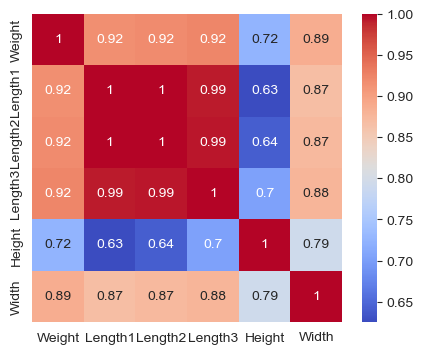

In [198]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

We can see that all the leghts are dependent so we need to perform some feature engineering

In [199]:
df['Volume'] = df['Height']*df['Length3']*df['Length1']
df['Height/Width'] = df['Height']/df['Width']
df['Height/Lenthdia'] = df['Height']/df['Length2']
df['K'] = 100*df['Weight']/df['Length3']**3
df['Roundness'] = df['Height'] / df['Length3']

In [200]:
df.drop('Length1', axis=1, inplace=True)
df.drop('Length3', axis=1, inplace=True)
df.drop('Weight', axis=1, inplace=True)
df.drop('Width', axis=1, inplace=True)
df.drop('Height', axis=1, inplace=True)

First thing first let`s decode oure target feature. We use labelencoder, becouse decision trees are not sensitive to scaling and they are not trying to fing math relationship such as between 0 and 2, that one is grater tha other, they are just trying to find the best split in the enery node

In [201]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [202]:
df['Species'] = encoder.fit_transform(df['Species'])

Let`s see the distribution of every feature

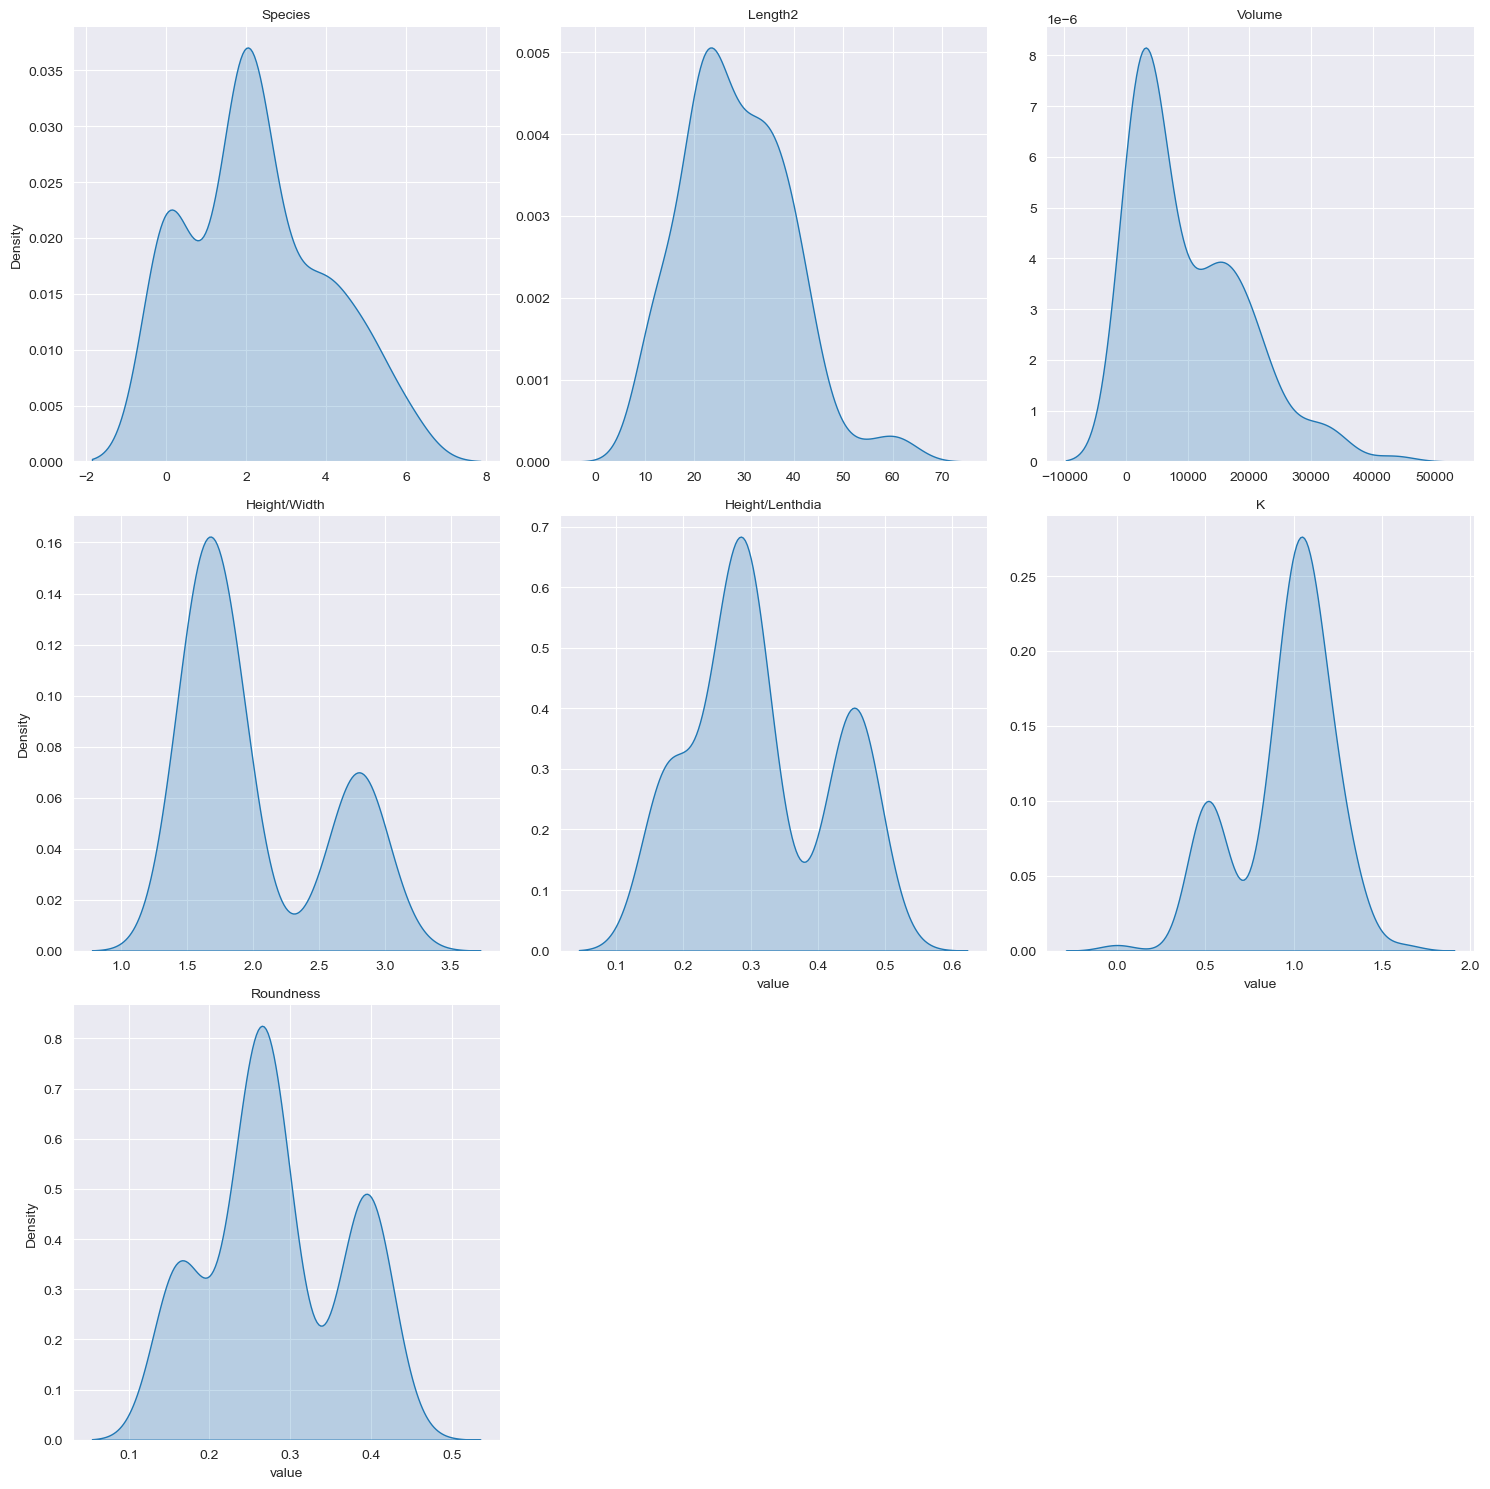

In [203]:
df_melted = df.melt()


g = sns.displot(
    data=df_melted, 
    x='value', 
    col='variable',
    kind='kde',
    col_wrap=3, 
    facet_kws={'sharex': False, 'sharey': False}, 
    fill=True
)

g.set_titles("{col_name}")
plt.show()

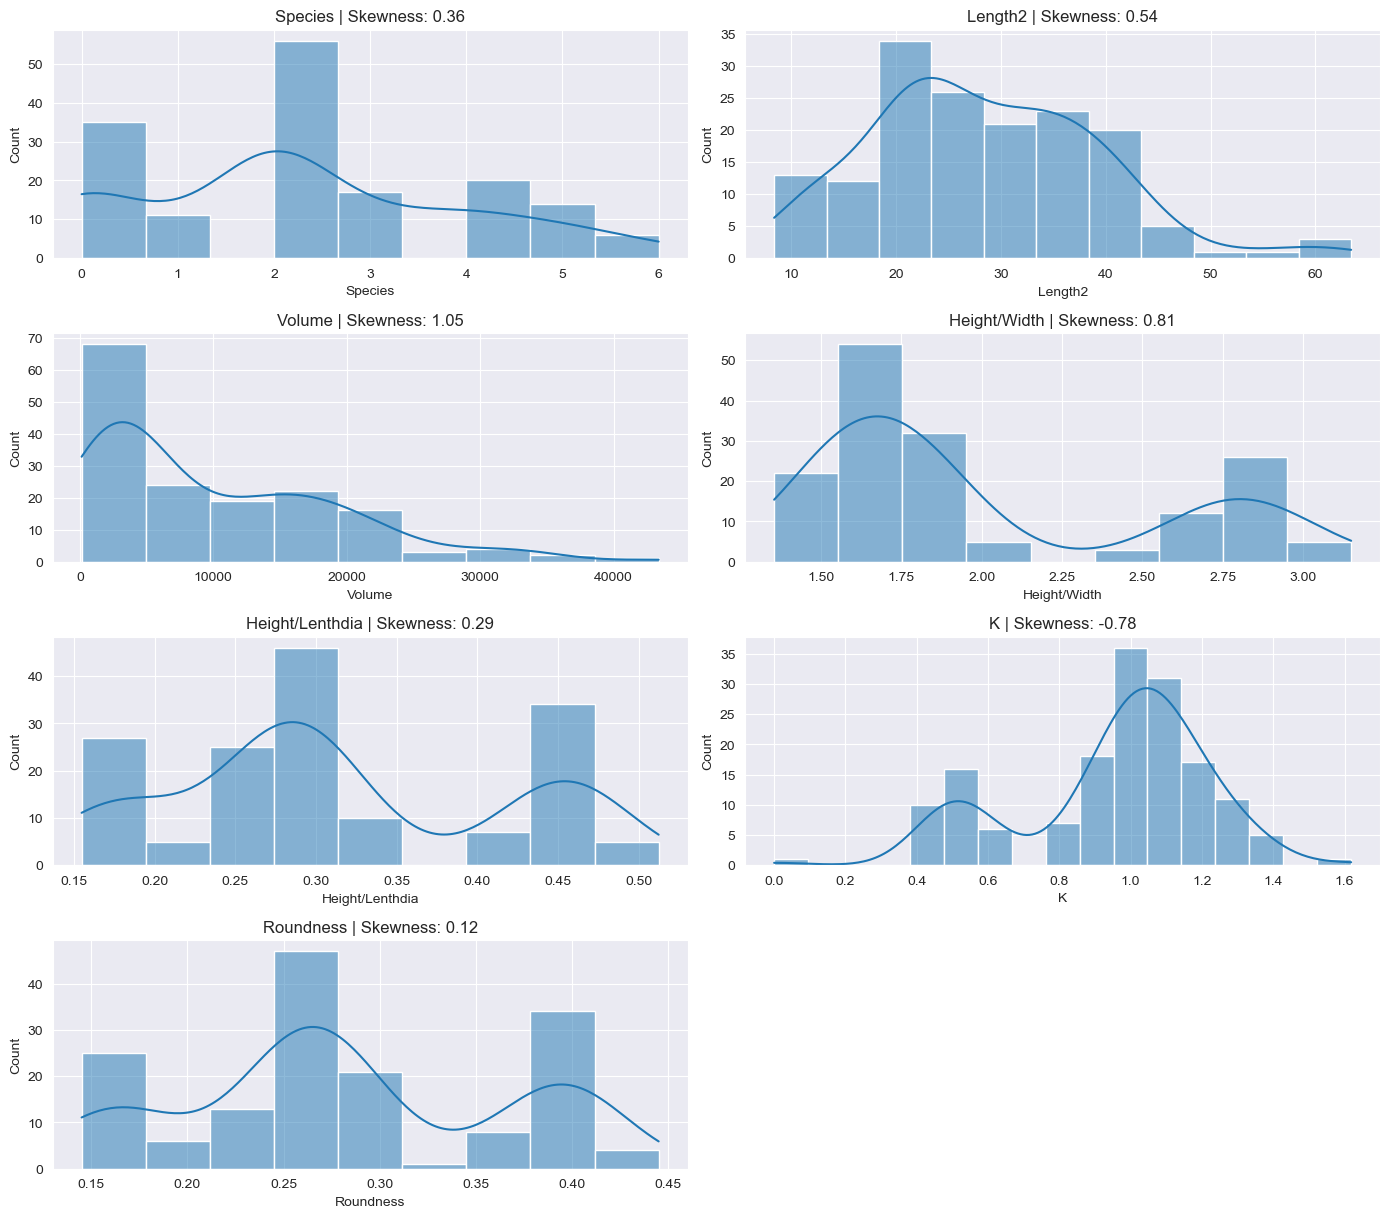

In [204]:
sns.set_style("darkgrid")

numerical_columns = df.columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Axes: xlabel='Species', ylabel='Volume'>

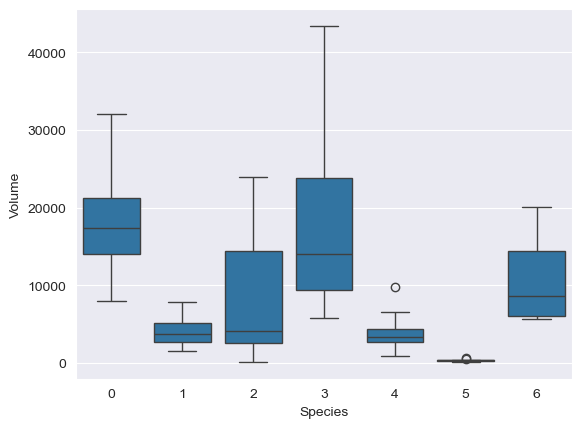

In [205]:
sns.boxplot(x='Species', y='Volume', data=df)

<Axes: >

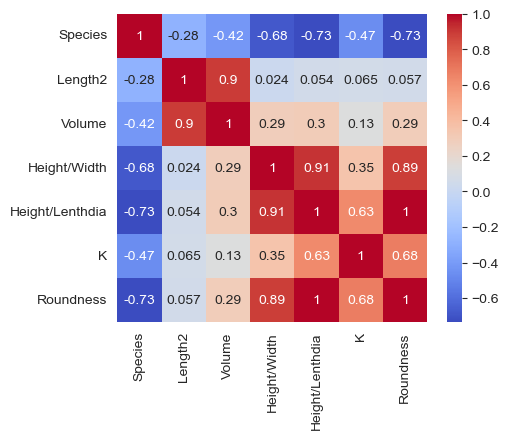

In [206]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [207]:
X = df.drop('Species', axis = 1)
y = df['Species']

In [208]:
from sklearn.model_selection import train_test_split

In [209]:
X_train, X_test, y_trai, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

In [210]:
num_features = ['Length2', 'Volume', 'Height/Width', 'Height/Lenthdia']

X_train[num_features] = X_train[num_features].apply(np.log1p)
X_test[num_features] = X_test[num_features].apply(np.log1p)

In [211]:
from sklearn.ensemble import RandomForestClassifier

In [279]:
weights = {0:1, 1:1, 2:2, 3:1, 4:2, 5:1, 6:2}

In [365]:
model = RandomForestClassifier(max_depth=5, n_estimators=50, oob_score=True, criterion='entropy', max_features='log2', class_weight=weights)

In [366]:
model.fit(X_train, y_trai)

RandomForestClassifier(class_weight={0: 1, 1: 1, 2: 2, 3: 1, 4: 2, 5: 1, 6: 2},
                       criterion='entropy', max_depth=5, max_features='log2',
                       n_estimators=50, oob_score=True)

In [346]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': {0: 1, 1: 1, 2: 2, 3: 1, 4: 2, 5: 1, 6: 2},
 'criterion': 'entropy',
 'max_depth': 6,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': True,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [368]:
model.oob_score_

0.8607594936708861

In [369]:
y_hat = model.predict(X_train)

In [370]:
y_pred = model.predict(X_test)

In [362]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [371]:
print(f"Accuracy train: {accuracy_score(y_trai, y_hat)}")
print(classification_report(y_trai, y_hat))

Accuracy train: 0.9873417721518988
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00         6
           2       0.97      1.00      0.98        28
           3       1.00      1.00      1.00         8
           4       1.00      0.90      0.95        10
           5       1.00      1.00      1.00         7
           6       1.00      1.00      1.00         3

    accuracy                           0.99        79
   macro avg       1.00      0.99      0.99        79
weighted avg       0.99      0.99      0.99        79



In [372]:
print(f"Accuracy на тесті: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy на тесті: 0.9125
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         5
           2       0.84      0.96      0.90        28
           3       1.00      1.00      1.00         9
           4       0.86      0.60      0.71        10
           5       1.00      1.00      1.00         7
           6       0.50      0.33      0.40         3

    accuracy                           0.91        80
   macro avg       0.89      0.84      0.86        80
weighted avg       0.91      0.91      0.91        80



In [221]:
from sklearn.model_selection import GridSearchCV

In [373]:
rf = RandomForestClassifier(random_state=42, class_weight=weights)
params = {
    "criterion": ["gini", "entropy"],
    'max_features':["log2","sqrt"],
    'max_depth': [2,3,4,5,6,7, 8, 9,10],
    'min_samples_leaf': [1,2,5,10,15,20,25,30,50,100],
    'n_estimators': [2,3,5,10,15,25,30,40,50, 100]
}

In [374]:
grid = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           scoring="accuracy",
                           verbose=3,
                           n_jobs=-1)

In [375]:
grid.fit(X_train, y_trai)

Fitting 4 folds for each of 3600 candidates, totalling 14400 fits


c:\Users\Julia\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(class_weight={0: 1, 1: 1, 2: 2,
                                                            3: 1, 4: 2, 5: 1,
                                                            6: 2},
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 2, 5, 10, 15, 20, 25, 30, 50,
                                              100],
                         'n_estimators': [2, 3, 5, 10, 15, 25, 30, 40, 50,
                                          100]},
             scoring='accuracy', verbose=3)

In [376]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 6,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'n_estimators': 15}

In [377]:
grid.best_score_


0.9111842105263158

In [378]:
y_hat = grid.predict(X_test)

In [379]:
print(f"Accuracy на тесті: {accuracy_score(y_test, y_hat)}")
print(classification_report(y_test, y_hat))

Accuracy на тесті: 0.9125
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         5
           2       0.87      0.96      0.92        28
           3       1.00      1.00      1.00         9
           4       0.88      0.70      0.78        10
           5       1.00      1.00      1.00         7
           6       0.00      0.00      0.00         3

    accuracy                           0.91        80
   macro avg       0.82      0.81      0.81        80
weighted avg       0.90      0.91      0.91        80



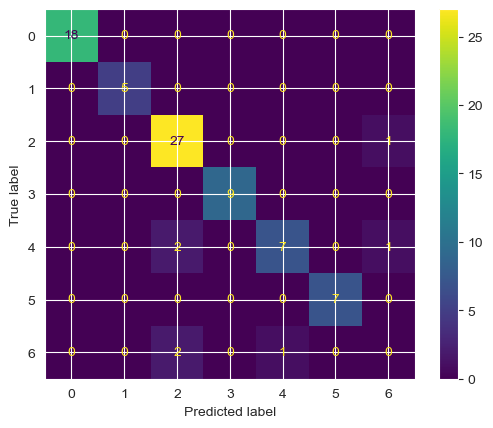

In [380]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = grid.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=grid.classes_).plot()

In [381]:
test_analysis = X_test.copy()
test_analysis['True_Label'] = y_test
test_analysis['Pred_Label'] = y_pred

errors = test_analysis[test_analysis['True_Label'] != test_analysis['Pred_Label']]

problem_errors = errors[errors['True_Label'].isin([2, 4, 6])]
print(f"Всього помилок: {len(errors)}")
print(problem_errors)

Всього помилок: 7
     Length2    Volume  Height/Width  Height/Lenthdia         K  Roundness  \
39  3.044522  7.850770      1.007641         0.270638  1.096787      0.280   
96  3.218876  8.316880      1.084819         0.265341  1.356944      0.286   
47  3.157000  8.124743      0.987387         0.250326  1.024000      0.256   
59  3.621671  9.661197      1.025739         0.279985  1.288263      0.297   
57  3.367296  8.842500      1.056053         0.272695  1.047296      0.285   
52  3.295837  8.735824      1.089917         0.293725  1.164795      0.304   
58  3.465736  9.250708      0.969758         0.297569  1.373906      0.316   

    True_Label  Pred_Label  
39           4           2  
96           2           6  
47           4           2  
59           6           2  
57           6           4  
52           4           6  
58           6           2  


In [ ]:
from sklearn.decomposition import PCA